In [24]:
import sys
import subprocess

packages = ["pandas", "numpy", "matplotlib", "seaborn", "openpyxl", "scikit-learn", "nltk"]
for package in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
nltk.download("stopwords")
nltk.download("wordnet")
print("Libraries loaded successfully.")

Libraries loaded successfully.


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\dzauakr.VW\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\dzauakr.VW\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [25]:
file_path = r"C:\Users\dzauakr.VW\Desktop\PGDip Data Analytics 2026\Programming for Data Analytics PDAN8411\ICE 3\Reviews.xlsx"
df = pd.read_excel(file_path, sheet_name="Reviews")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print(df.columns.tolist())
display(df.head())

Rows: 568454
Columns: 10
['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator', 'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text']


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [26]:
df.info()
display(df.describe(include="all"))

<class 'pandas.DataFrame'>
RangeIndex: 568454 entries, 0 to 568453
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   Id                      568454 non-null  int64 
 1   ProductId               568454 non-null  object
 2   UserId                  568454 non-null  str   
 3   ProfileName             568358 non-null  object
 4   HelpfulnessNumerator    568454 non-null  int64 
 5   HelpfulnessDenominator  568454 non-null  int64 
 6   Score                   568454 non-null  int64 
 7   Time                    568454 non-null  int64 
 8   Summary                 568417 non-null  object
 9   Text                    568454 non-null  str   
dtypes: int64(5), object(3), str(2)
memory usage: 287.3+ MB


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
count,568454.000000,568454,568454,568358,568454.000000,568454.00000,568454.000000,5.684540e+05,568417,568454
unique,NaN,74258,256059,218398,NaN,NaN,NaN,NaN,295735,393579
top,NaN,B007JFMH8M,A3OXHLG6DIBRW8,"C. F. Hill ""CFH""",NaN,NaN,NaN,NaN,Delicious!,"This review will make me sound really stupid, ..."
freq,NaN,913,448,451,NaN,NaN,NaN,NaN,2462,199
mean,284227.500000,NaN,NaN,NaN,1.743817,2.22881,4.183199,1.296257e+09,NaN,NaN
std,164098.679298,NaN,NaN,NaN,7.636513,8.28974,1.310436,4.804331e+07,NaN,NaN
min,1.000000,NaN,NaN,NaN,0.000000,0.00000,1.000000,9.393408e+08,NaN,NaN
25%,142114.250000,NaN,NaN,NaN,0.000000,0.00000,4.000000,1.271290e+09,NaN,NaN
50%,284227.500000,NaN,NaN,NaN,0.000000,1.00000,5.000000,1.311120e+09,NaN,NaN
75%,426340.750000,NaN,NaN,NaN,2.000000,2.00000,5.000000,1.332720e+09,NaN,NaN


In [27]:
missing_values = df.isnull().sum()
missing_percentage = df.isnull().sum() / len(df) * 100
missing_summary = pd.DataFrame({"Missing Values": missing_values, "Percentage": missing_percentage})
display(missing_summary)
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate review texts:", df["Text"].duplicated().sum())

,Missing Values,Percentage
Id,0,0.000000
ProductId,0,0.000000
UserId,0,0.000000
ProfileName,96,0.016888
HelpfulnessNumerator,0,0.000000
HelpfulnessDenominator,0,0.000000
Score,0,0.000000
Time,0,0.000000
Summary,37,0.006509
Text,0,0.000000


Duplicate rows: 0
Duplicate review texts: 174875


In [28]:
reviews = df.copy()
reviews = reviews.dropna(subset=["Text"])
reviews["Summary"] = reviews["Summary"].fillna("")
reviews = reviews.drop_duplicates(subset=["Text"])
print("Rows after cleaning:", len(reviews))

Rows after cleaning: 393579


Score
1     36275
2     20792
3     29754
4     56042
5    250716
Name: count, dtype: int64

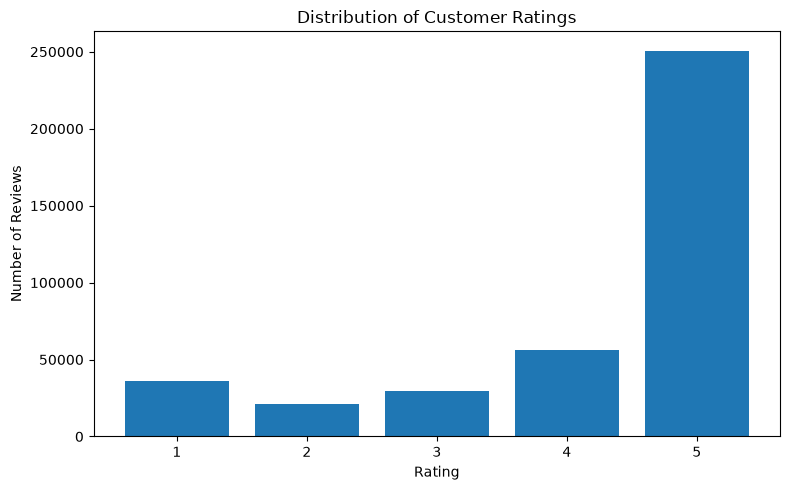

In [29]:
rating_counts = reviews["Score"].value_counts().sort_index()
display(rating_counts)
plt.figure(figsize=(8,5))
plt.bar(rating_counts.index.astype(str), rating_counts.values)
plt.title("Distribution of Customer Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")
plt.tight_layout()
plt.show()

In [30]:
sentiment_df = reviews[reviews["Score"] != 3].copy()
sentiment_df["Sentiment"] = np.where(sentiment_df["Score"] >= 4, 1, 0)
print(sentiment_df["Sentiment"].value_counts())
print(sentiment_df["Sentiment"].value_counts(normalize=True) * 100)

Sentiment
1    306758
0     57067
Name: count, dtype: int64
Sentiment
1    84.314712
0    15.685288
Name: proportion, dtype: float64


In [31]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    words = text.split()
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    return " ".join(words)
sentiment_df["Clean_Text"] = sentiment_df["Text"].apply(clean_text)
sentiment_df = sentiment_df[sentiment_df["Clean_Text"].str.strip() != ""].copy()
display(sentiment_df[["Text", "Clean_Text"]].head())

,Text,Clean_Text
0,I have bought several of the Vitality canned d...,bought several vitality canned dog food produc...
1,Product arrived labeled as Jumbo Salted Peanut...,product arrived labeled jumbo salted peanut pe...
2,This is a confection that has been around a fe...,confection around century light pillowy citrus...
3,If you are looking for the secret ingredient i...,looking secret ingredient robitussin believe f...
4,Great taffy at a great price. There was a wid...,great taffy great price wide assortment yummy ...


count    363824.000000
mean         38.677982
std          38.398053
min           1.000000
25%          17.000000
50%          27.000000
75%          47.000000
max        1564.000000
Name: Review_Length, dtype: float64

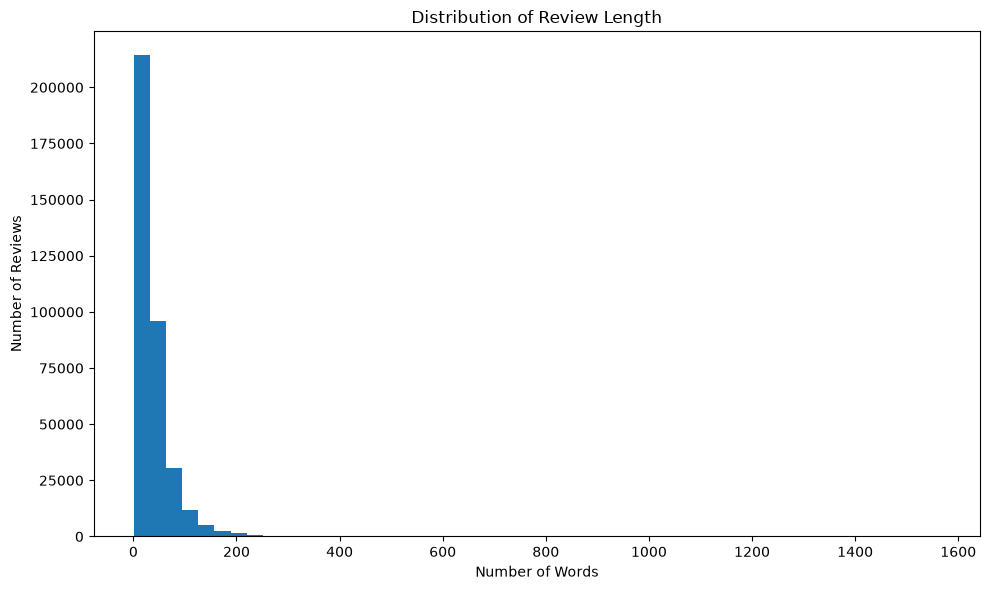

In [32]:
sentiment_df["Review_Length"] = sentiment_df["Clean_Text"].str.split().str.len()
display(sentiment_df["Review_Length"].describe())
plt.figure(figsize=(10,6))
plt.hist(sentiment_df["Review_Length"], bins=50)
plt.title("Distribution of Review Length")
plt.xlabel("Number of Words")
plt.ylabel("Number of Reviews")
plt.tight_layout()
plt.show()

,Word,Frequency
0,like,161358
1,taste,135704
2,good,126914
3,product,119957
4,one,118352
5,flavor,111588
6,great,109537
7,love,100180
8,tea,95689
9,coffee,94567


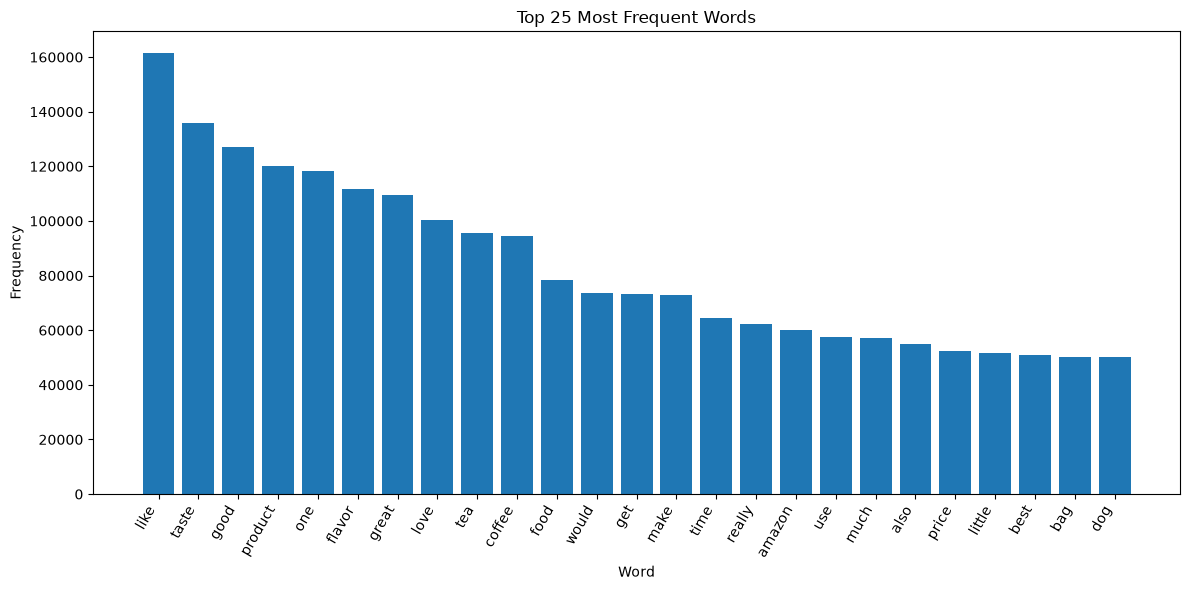

In [33]:
all_words = " ".join(sentiment_df["Clean_Text"])
word_counts = Counter(all_words.split())
top_words_df = pd.DataFrame(word_counts.most_common(25), columns=["Word","Frequency"])
display(top_words_df)
plt.figure(figsize=(12,6))
plt.bar(top_words_df["Word"], top_words_df["Frequency"])
plt.title("Top 25 Most Frequent Words")
plt.xlabel("Word")
plt.ylabel("Frequency")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

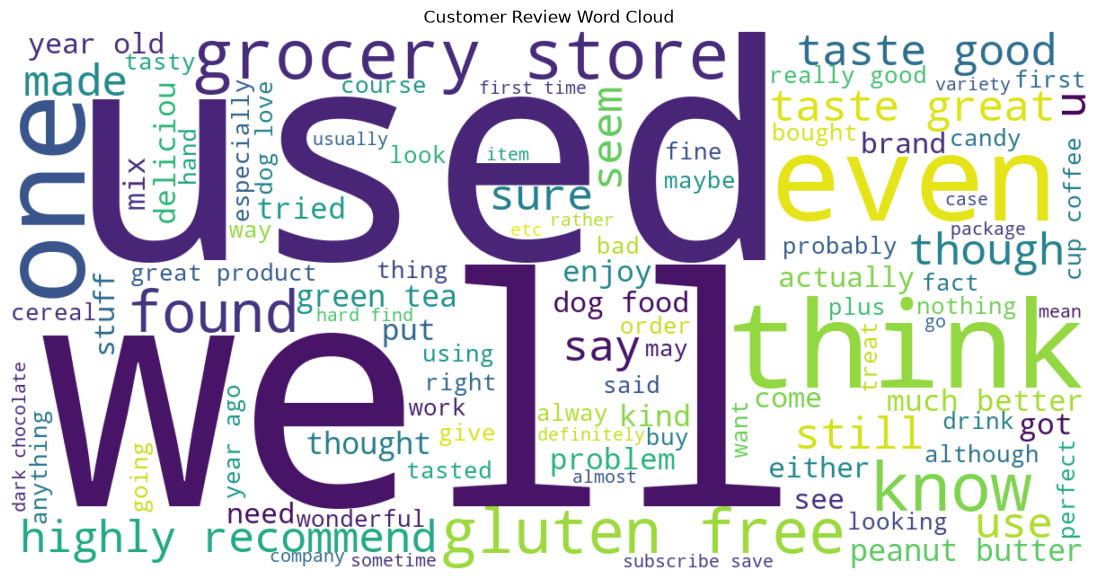

In [34]:
try:
    from wordcloud import WordCloud
    wordcloud = WordCloud(width=1200,height=600,background_color="white",max_words=100).generate(all_words)
    plt.figure(figsize=(14,7))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title("Customer Review Word Cloud")
    plt.show()
except ModuleNotFoundError:
    print("WordCloud is not installed. Continuing without WordCloud.")

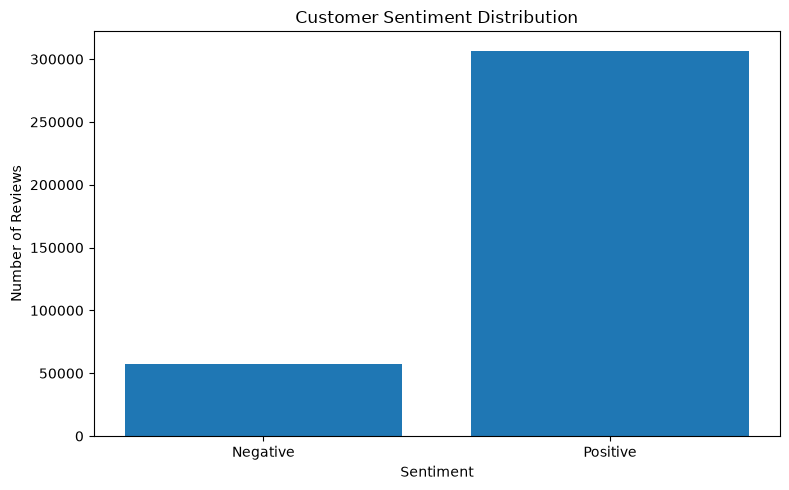

Negative reviews: 57067
Positive reviews: 306757


In [35]:
sentiment_counts = sentiment_df["Sentiment"].value_counts().sort_index()
plt.figure(figsize=(8,5))
plt.bar(["Negative","Positive"], sentiment_counts.values)
plt.title("Customer Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.tight_layout()
plt.show()
print("Negative reviews:", sentiment_counts.get(0,0))
print("Positive reviews:", sentiment_counts.get(1,0))

In [36]:
RANDOM_STATE=42
SAMPLE_SIZE=min(100000,len(sentiment_df))
model_df,_=train_test_split(sentiment_df,train_size=SAMPLE_SIZE,random_state=RANDOM_STATE,stratify=sentiment_df["Sentiment"])
model_df=model_df.reset_index(drop=True)
print("Reviews used for modelling:",len(model_df))

Reviews used for modelling: 100000


In [37]:
X=model_df["Clean_Text"]
y=model_df["Sentiment"]
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=RANDOM_STATE,stratify=y)
print("Training reviews:",len(X_train))
print("Testing reviews:",len(X_test))

Training reviews: 80000
Testing reviews: 20000


In [38]:
tfidf=TfidfVectorizer(max_features=30000,ngram_range=(1,2),min_df=5,max_df=0.95,sublinear_tf=True)
X_train_tfidf=tfidf.fit_transform(X_train)
X_test_tfidf=tfidf.transform(X_test)
print("Training feature matrix:",X_train_tfidf.shape)
print("Testing feature matrix:",X_test_tfidf.shape)

Training feature matrix: (80000, 30000)
Testing feature matrix: (20000, 30000)


In [39]:
logistic_model=LogisticRegression(max_iter=1000,C=1.0,class_weight="balanced",random_state=RANDOM_STATE)
logistic_model.fit(X_train_tfidf,y_train)
logistic_predictions=logistic_model.predict(X_test_tfidf)
logistic_accuracy=accuracy_score(y_test,logistic_predictions)
logistic_precision=precision_score(y_test,logistic_predictions)
logistic_recall=recall_score(y_test,logistic_predictions)
logistic_f1=f1_score(y_test,logistic_predictions)
print("LOGISTIC REGRESSION")
print("Accuracy:",round(logistic_accuracy,4))
print("Precision:",round(logistic_precision,4))
print("Recall:",round(logistic_recall,4))
print("F1 Score:",round(logistic_f1,4))
print(classification_report(y_test,logistic_predictions,target_names=["Negative","Positive"]))

LOGISTIC REGRESSION
Accuracy: 0.9043
Precision: 0.9731
Recall: 0.9117
F1 Score: 0.9414
              precision    recall  f1-score   support

    Negative       0.65      0.86      0.74      3137
    Positive       0.97      0.91      0.94     16863

    accuracy                           0.90     20000
   macro avg       0.81      0.89      0.84     20000
weighted avg       0.92      0.90      0.91     20000



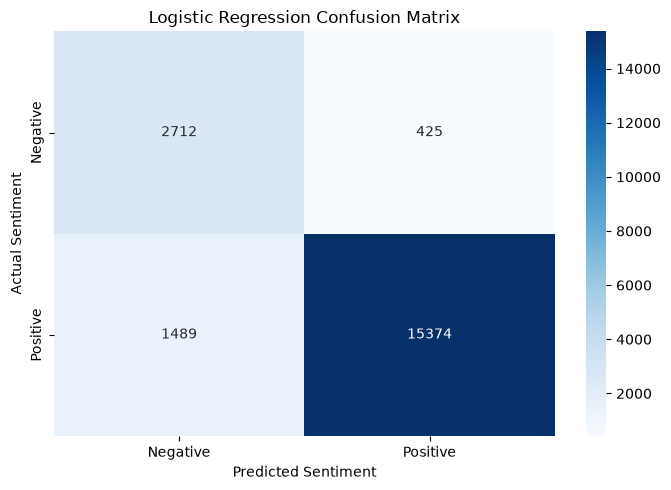

In [40]:
cm=confusion_matrix(y_test,logistic_predictions)
plt.figure(figsize=(7,5))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",xticklabels=["Negative","Positive"],yticklabels=["Negative","Positive"])
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")
plt.tight_layout()
plt.show()

In [41]:
svm_model=LinearSVC(C=1.0,class_weight="balanced",random_state=RANDOM_STATE)
svm_model.fit(X_train_tfidf,y_train)
svm_predictions=svm_model.predict(X_test_tfidf)
svm_accuracy=accuracy_score(y_test,svm_predictions)
svm_precision=precision_score(y_test,svm_predictions)
svm_recall=recall_score(y_test,svm_predictions)
svm_f1=f1_score(y_test,svm_predictions)
print("LINEAR SVM")
print("Accuracy:",round(svm_accuracy,4))
print("Precision:",round(svm_precision,4))
print("Recall:",round(svm_recall,4))
print("F1 Score:",round(svm_f1,4))
print(classification_report(y_test,svm_predictions,target_names=["Negative","Positive"]))

LINEAR SVM
Accuracy: 0.9141
Precision: 0.9637
Recall: 0.9333
F1 Score: 0.9482
              precision    recall  f1-score   support

    Negative       0.69      0.81      0.75      3137
    Positive       0.96      0.93      0.95     16863

    accuracy                           0.91     20000
   macro avg       0.83      0.87      0.85     20000
weighted avg       0.92      0.91      0.92     20000



In [42]:
model_results=pd.DataFrame({"Model":["Logistic Regression","Linear SVM"],"Accuracy":[logistic_accuracy,svm_accuracy],"Precision":[logistic_precision,svm_precision],"Recall":[logistic_recall,svm_recall],"F1 Score":[logistic_f1,svm_f1]})
display(model_results.round(4))

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.9043,0.9731,0.9117,0.9414
1,Linear SVM,0.9141,0.9637,0.9333,0.9482


In [43]:
TOPIC_SAMPLE_SIZE=min(50000,len(sentiment_df))
topic_df=sentiment_df.sample(n=TOPIC_SAMPLE_SIZE,random_state=RANDOM_STATE).copy()
count_vectorizer=CountVectorizer(max_features=10000,min_df=10,max_df=0.95,stop_words="english")
X_topics=count_vectorizer.fit_transform(topic_df["Clean_Text"])
NUMBER_OF_TOPICS=6
lda_model=LatentDirichletAllocation(n_components=NUMBER_OF_TOPICS,random_state=RANDOM_STATE,learning_method="batch",max_iter=20)
lda_model.fit(X_topics)
feature_names=count_vectorizer.get_feature_names_out()
for topic_number,topic in enumerate(lda_model.components_):
    top_indices=topic.argsort()[-10:][::-1]
    top_topic_words=[feature_names[index] for index in top_indices]
    print(f"Topic {topic_number+1}: {', '.join(top_topic_words)}")

Topic 1: food, dog, cat, treat, love, like, product, day, eat, time
Topic 2: coffee, taste, flavor, like, tea, cup, drink, good, water, great
Topic 3: like, use, make, sauce, flavor, taste, oil, good, product, great
Topic 4: taste, like, good, sugar, bar, snack, great, flavor, eat, love
Topic 5: amazon, price, store, tea, great, buy, product, love, bag, local
Topic 6: product, box, good, order, like, great, time, bag, ordered, candy


Dominant_Topic
1     6445
2    10939
3     8300
4     8728
5     6547
6     9041
Name: count, dtype: int64

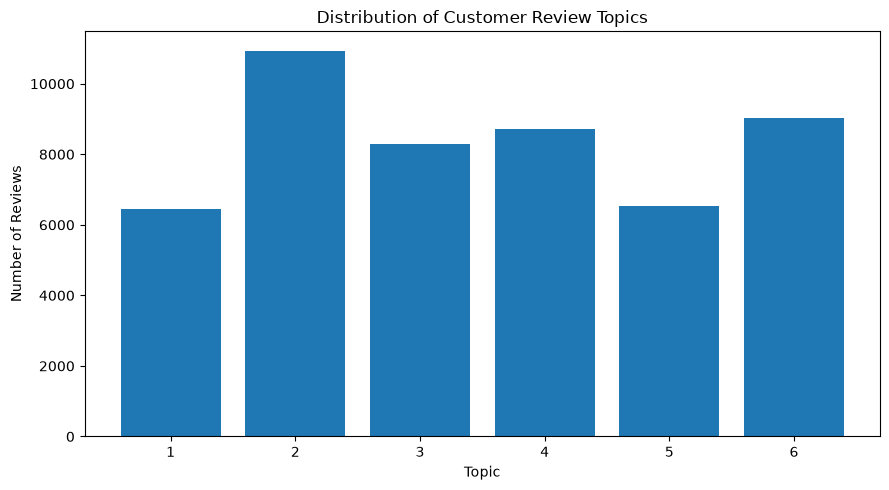

In [44]:
topic_probabilities=lda_model.transform(X_topics)
topic_df["Dominant_Topic"]=topic_probabilities.argmax(axis=1)+1
topic_counts=topic_df["Dominant_Topic"].value_counts().sort_index()
display(topic_counts)
plt.figure(figsize=(9,5))
plt.bar(topic_counts.index.astype(str),topic_counts.values)
plt.title("Distribution of Customer Review Topics")
plt.xlabel("Topic")
plt.ylabel("Number of Reviews")
plt.tight_layout()
plt.show()

In [45]:
feature_names_tfidf=tfidf.get_feature_names_out()
coefficients=logistic_model.coef_[0]
positive_indices=coefficients.argsort()[-20:][::-1]
negative_indices=coefficients.argsort()[:20]
positive_words=pd.DataFrame({"Word":feature_names_tfidf[positive_indices],"Coefficient":coefficients[positive_indices]})
negative_words=pd.DataFrame({"Word":feature_names_tfidf[negative_indices],"Coefficient":coefficients[negative_indices]})
print("Strongest positive sentiment terms")
display(positive_words)
print("Strongest negative sentiment terms")
display(negative_words)

Strongest positive sentiment terms


,Word,Coefficient
0,great,13.335895
1,best,11.180627
2,delicious,10.386245
3,love,9.688734
4,perfect,9.107118
5,excellent,7.730547
6,wonderful,7.070438
7,favorite,6.646962
8,good,6.370714
9,amazing,6.308169


Strongest negative sentiment terms


,Word,Coefficient
0,disappointed,-8.829534
1,worst,-8.816026
2,disappointing,-8.379705
3,terrible,-7.170169
4,unfortunately,-6.987399
5,disappointment,-6.762184
6,awful,-6.716943
7,horrible,-6.122227
8,weak,-5.866598
9,bland,-5.687574


In [46]:
summary=pd.DataFrame({"Measure":["Original reviews","Cleaned reviews","Modelling reviews","Topic modelling reviews","Negative reviews","Positive reviews","Logistic Regression Accuracy","Logistic Regression F1","Linear SVM Accuracy","Linear SVM F1","Number of LDA topics"],"Value":[len(df),len(reviews),len(model_df),len(topic_df),int(sentiment_counts.get(0,0)),int(sentiment_counts.get(1,0)),round(logistic_accuracy,4),round(logistic_f1,4),round(svm_accuracy,4),round(svm_f1,4),NUMBER_OF_TOPICS]})
display(summary)

,Measure,Value
0,Original reviews,568454.0000
1,Cleaned reviews,393579.0000
2,Modelling reviews,100000.0000
3,Topic modelling reviews,50000.0000
4,Negative reviews,57067.0000
5,Positive reviews,306757.0000
6,Logistic Regression Accuracy,0.9043
7,Logistic Regression F1,0.9414
8,Linear SVM Accuracy,0.9141
9,Linear SVM F1,0.9482
